# 🚦 Event-Driven Congestion Prediction
## Astram Traffic Events — ML Model

**Problem Statement:**  
*How can historical and real-time data be used to forecast event-related traffic impact and recommend optimal manpower, barricading, and diversion plans?*

---

### What this notebook does:
1. Loads and explores the Astram traffic event dataset
2. Engineers useful features from raw event data
3. Trains **two ML models**:
   - **Model 1** → Predicts **Priority** (High / Low) — helps allocate manpower
   - **Model 2** → Predicts **Road Closure Required** (Yes / No) — helps plan barricading
4. Evaluates both models with metrics and visualizations

> **Dataset:** Bengaluru traffic events collected by the Astram system (anonymized)


## 📦 Step 1: Import Libraries

We use:
- `pandas` and `numpy` for data handling
- `scikit-learn` for building ML models
- `matplotlib` for plots


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 Step 2: Load the Dataset

We load the CSV file and take a first look at its shape and columns.


In [2]:
# Load the dataset
# Update the path below if your file is in a different location
link = "https://raw.githubusercontent.com/Niladri13072004/dataset/refs/heads/main/Astram%20event%20data_anonymized%20-%20Astram%20event%20data_anonymizedb40ac87.csv"
df = pd.read_csv(link)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print("Column names:")
for col in df.columns:
    print(f"  - {col}")


Dataset shape: 8173 rows × 46 columns

Column names:
  - id
  - event_type
  - latitude
  - longitude
  - endlatitude
  - endlongitude
  - address
  - end_address
  - event_cause
  - requires_road_closure
  - start_datetime
  - end_datetime
  - status
  - authenticated
  - modified_datetime
  - map_file
  - direction
  - description
  - veh_type
  - veh_no
  - corridor
  - priority
  - cargo_material
  - reason_breakdown
  - age_of_truck
  - created_date
  - route_path
  - client_id
  - created_by_id
  - last_modified_by_id
  - assigned_to_police_id
  - citizen_accident_id
  - comment
  - police_station
  - meta_data
  - kgid
  - resolved_at_address
  - resolved_at_latitude
  - resolved_at_longitude
  - closed_by_id
  - closed_datetime
  - resolved_by_id
  - resolved_datetime
  - gba_identifier
  - zone
  - junction


In [3]:
# Show first 3 rows to understand the data
df.head(3)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.0,0.0,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.0,0.0,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.0,0.0,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction


## 🔍 Step 3: Exploratory Data Analysis (EDA)

Before building any model, we need to understand:
- What types of events are in the data?
- What are the target variables (what we want to predict)?
- Are there any missing values?


In [4]:
# Distribution of event causes (the "type" of traffic problem)
print("📌 Event Cause Distribution:")
print(df['event_cause'].value_counts())
print()

# Distribution of Priority — this is Target Variable 1
print("🎯 Priority (Target 1):")
print(df['priority'].value_counts())
print()

# Distribution of Road Closure — this is Target Variable 2
print("🚧 Requires Road Closure (Target 2):")
print(df['requires_road_closure'].value_counts())


📌 Event Cause Distribution:
event_cause
vehicle_breakdown       4896
others                   638
pot_holes                537
construction             480
water_logging            458
accident                 365
tree_fall                284
road_conditions          170
congestion               136
public_event              84
procession                72
vip_movement              20
protest                   15
Debris                    12
test_demo                  3
Fog / Low Visibility       2
debris                     1
Name: count, dtype: int64

🎯 Priority (Target 1):
priority
High    5030
Low     3141
Name: count, dtype: int64

🚧 Requires Road Closure (Target 2):
requires_road_closure
False    7497
True      676
Name: count, dtype: int64


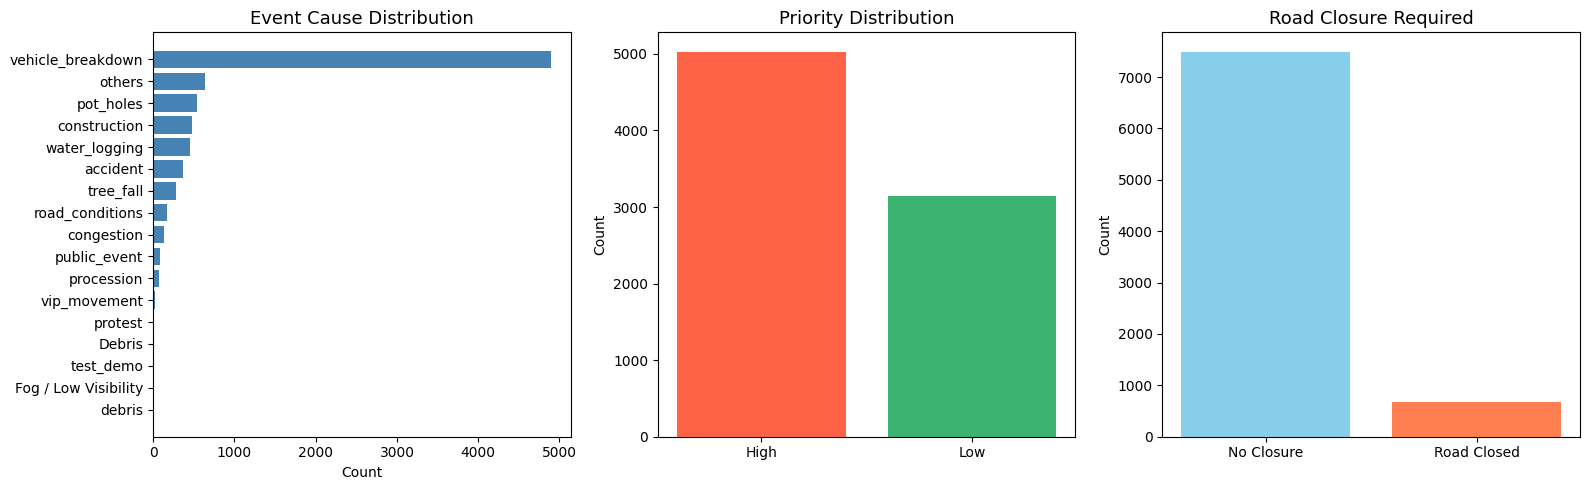

📊 Chart saved as eda_distributions.png


In [5]:
# Visualise the key distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Event causes
cause_counts = df['event_cause'].value_counts()
axes[0].barh(cause_counts.index, cause_counts.values, color='steelblue')
axes[0].set_title('Event Cause Distribution', fontsize=13)
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Plot 2: Priority
priority_counts = df['priority'].value_counts()
axes[1].bar(priority_counts.index, priority_counts.values,
            color=['tomato', 'mediumseagreen'])
axes[1].set_title('Priority Distribution', fontsize=13)
axes[1].set_ylabel('Count')

# Plot 3: Road Closure
closure_counts = df['requires_road_closure'].value_counts()
axes[2].bar(['No Closure', 'Road Closed'],
            closure_counts.values, color=['skyblue', 'coral'])
axes[2].set_title('Road Closure Required', fontsize=13)
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("📊 Chart saved as eda_distributions.png")


In [6]:
# Check missing values for columns we plan to use
key_cols = ['event_cause', 'event_type', 'priority', 'requires_road_closure',
            'corridor', 'latitude', 'longitude', 'veh_type', 'zone']

print("🔎 Missing values in key columns:")
missing = df[key_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)


🔎 Missing values in key columns:
                       Missing Count  Missing %
event_cause                        0        0.0
event_type                         0        0.0
priority                           2        0.0
requires_road_closure              0        0.0
corridor                          20        0.2
latitude                           0        0.0
longitude                          0        0.0
veh_type                        3286       40.2
zone                            4729       57.9


## 🛠️ Step 4: Feature Engineering

We select and transform the raw columns into features the ML model can use.

**Features we'll use:**
| Feature | Why it's useful |
|---|---|
| `event_cause` | Root cause of congestion (vehicle breakdown, tree fall, etc.) |
| `event_type` | Planned vs Unplanned event |
| `corridor` | Which road/corridor the event is on |
| `latitude` / `longitude` | Geographic location |
| `veh_type` | Type of vehicle involved (if any) |
| `requires_road_closure` | Whether road needs to be blocked |

**Targets:**
- **Model 1:** `priority` → High or Low manpower needed
- **Model 2:** `requires_road_closure` → Whether to deploy barricades


In [7]:
# ── Select relevant features ──────────────────────────────────────────────────
FEATURE_COLS = ['event_cause', 'event_type', 'corridor', 'latitude',
                'longitude', 'veh_type']

TARGET_PRIORITY = 'priority'
TARGET_CLOSURE  = 'requires_road_closure'

# Work on a clean copy
data = df[FEATURE_COLS + [TARGET_PRIORITY, TARGET_CLOSURE]].copy()

print(f"Working dataset shape: {data.shape}")
print()

# ── Drop rows where target is missing (only 2 rows for priority) ──────────────
data = data.dropna(subset=[TARGET_PRIORITY])
print(f"After dropping rows with missing target: {data.shape}")


Working dataset shape: (8173, 8)

After dropping rows with missing target: (8171, 8)


In [8]:
# ── Fill missing categorical features with 'Unknown' ─────────────────────────
cat_cols = ['event_cause', 'event_type', 'corridor', 'veh_type']
for col in cat_cols:
    data[col] = data[col].fillna('Unknown')

# ── Encode categorical columns into numbers ───────────────────────────────────
# LabelEncoder converts text labels → integers  (e.g. 'High'→1, 'Low'→0)
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col + '_enc'] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"Encoded '{col}': {list(le.classes_[:5])} ...")

# Encode targets
le_priority = LabelEncoder()
data['priority_enc'] = le_priority.fit_transform(data[TARGET_PRIORITY])
data['closure_enc'] = data[TARGET_CLOSURE].astype(int)   # True→1, False→0

print()
print("Priority classes:", le_priority.classes_)   # 0=High, 1=Low (or vice versa)
print("Closure: 0=No, 1=Yes")


Encoded 'event_cause': ['Debris', 'Fog / Low Visibility', 'accident', 'congestion', 'construction'] ...
Encoded 'event_type': ['planned', 'unplanned'] ...
Encoded 'corridor': ['Airport New South Road', 'Bannerghata Road', 'Bellary Road 1', 'Bellary Road 2', 'CBD 1'] ...
Encoded 'veh_type': ['Unknown', 'auto', 'bmtc_bus', 'heavy_vehicle', 'ksrtc_bus'] ...

Priority classes: ['High' 'Low']
Closure: 0=No, 1=Yes


In [9]:
# ── Define final feature matrix X ─────────────────────────────────────────────
encoded_cat_cols = [c + '_enc' for c in cat_cols]
numeric_cols     = ['latitude', 'longitude']

X = data[encoded_cat_cols + numeric_cols]
y_priority = data['priority_enc']
y_closure  = data['closure_enc']

print(f"Feature matrix X shape : {X.shape}")
print(f"Target 1 (priority) shape: {y_priority.shape}")
print(f"Target 2 (closure) shape : {y_closure.shape}")
print()
print("Features used:", list(X.columns))


Feature matrix X shape : (8171, 6)
Target 1 (priority) shape: (8171,)
Target 2 (closure) shape : (8171,)

Features used: ['event_cause_enc', 'event_type_enc', 'corridor_enc', 'veh_type_enc', 'latitude', 'longitude']


## 🤖 Step 5: Model 1 — Predict Traffic Priority (High / Low)

**Goal:** Given an event, predict whether it needs **High** or **Low** priority response (i.e., how much manpower to deploy).

We use a **Random Forest** classifier — it builds many decision trees and combines their votes, making it robust and accurate.


In [10]:
# ── Train-test split: 80% train, 20% test ────────────────────────────────────
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y_priority, test_size=0.2, random_state=42, stratify=y_priority
)

print(f"Training samples : {len(X_train1)}")
print(f"Testing  samples : {len(X_test1)}")


Training samples : 6536
Testing  samples : 1635


In [11]:
# ── Build and train the Random Forest model ───────────────────────────────────
# n_estimators = number of trees (100 is a good default)
# class_weight = 'balanced' handles any imbalance in High vs Low counts

rf_priority = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_priority.fit(X_train1, y_train1)
print("✅ Model 1 (Priority) trained successfully!")


✅ Model 1 (Priority) trained successfully!


In [12]:
# ── Evaluate Model 1 ──────────────────────────────────────────────────────────
y_pred1 = rf_priority.predict(X_test1)

acc1 = accuracy_score(y_test1, y_pred1)
print(f"🎯 Model 1 Accuracy: {acc1*100:.2f}%")
print()

# Classification report shows Precision, Recall, F1 for each class
class_names = le_priority.classes_
print("📋 Detailed Classification Report:")
print(classification_report(y_test1, y_pred1, target_names=class_names))


🎯 Model 1 Accuracy: 99.82%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1006
         Low       1.00      1.00      1.00       629

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



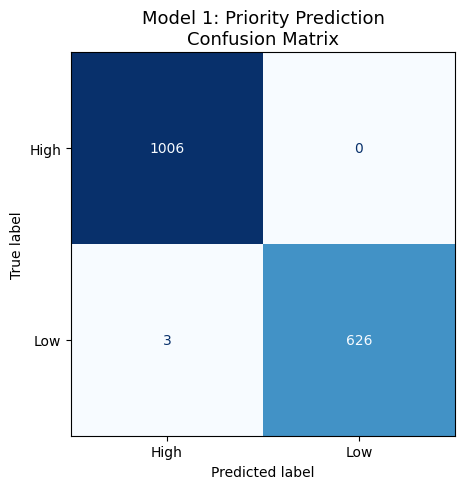

📊 Saved as confusion_matrix_priority.png


In [13]:
# ── Confusion Matrix for Model 1 ─────────────────────────────────────────────
# Shows how many predictions were correct vs wrong for each class

fig, ax = plt.subplots(figsize=(6, 5))
cm1 = confusion_matrix(y_test1, y_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)
disp1.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Model 1: Priority Prediction\nConfusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_priority.png', dpi=100, bbox_inches='tight')
plt.show()
print("📊 Saved as confusion_matrix_priority.png")


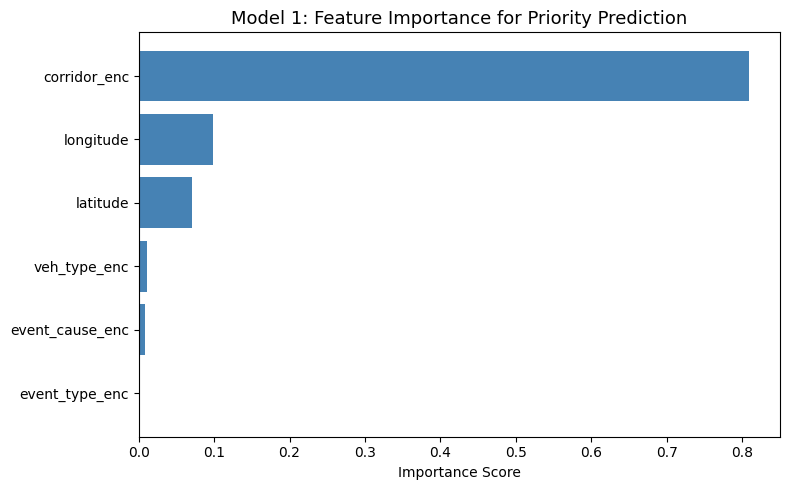

In [14]:
# ── Feature Importance for Model 1 ───────────────────────────────────────────
# Which features matter most for predicting priority?

feature_names = encoded_cat_cols + numeric_cols
importances1 = rf_priority.feature_importances_
feat_df1 = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances1
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df1['Feature'], feat_df1['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Model 1: Feature Importance for Priority Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance_priority.png', dpi=100, bbox_inches='tight')
plt.show()


## 🚧 Step 6: Model 2 — Predict Road Closure Required (Yes / No)

**Goal:** Predict whether an event will **require road closure** — so authorities can pre-position barricades and plan diversions.

Since road closures are relatively rare (only ~8% of events), we use **Gradient Boosting** — it focuses extra attention on the hard-to-predict minority class.


In [15]:
# ── Train-test split for Model 2 ─────────────────────────────────────────────
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_closure, test_size=0.2, random_state=42, stratify=y_closure
)

print(f"Training samples : {len(X_train2)}")
print(f"Testing  samples : {len(X_test2)}")
print()
print("Class distribution in training set:")
print(pd.Series(y_train2).value_counts().rename({0: 'No Closure', 1: 'Closure'}))


Training samples : 6536
Testing  samples : 1635

Class distribution in training set:
closure_enc
No Closure    5995
Closure        541
Name: count, dtype: int64


In [16]:
# ── Build and train Gradient Boosting model ───────────────────────────────────
# Gradient Boosting builds trees one by one, each tree fixing the previous one's errors

gb_closure = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,    # How fast the model learns (lower = more careful)
    max_depth=4,           # Depth of each tree
    random_state=42
)

gb_closure.fit(X_train2, y_train2)
print("✅ Model 2 (Road Closure) trained successfully!")


✅ Model 2 (Road Closure) trained successfully!


In [17]:
# ── Evaluate Model 2 ──────────────────────────────────────────────────────────
y_pred2 = gb_closure.predict(X_test2)

acc2 = accuracy_score(y_test2, y_pred2)
print(f"🎯 Model 2 Accuracy: {acc2*100:.2f}%")
print()

print("📋 Detailed Classification Report:")
print(classification_report(y_test2, y_pred2,
                            target_names=['No Closure', 'Road Closed']))


🎯 Model 2 Accuracy: 91.99%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

  No Closure       0.93      0.98      0.96      1500
 Road Closed       0.54      0.20      0.29       135

    accuracy                           0.92      1635
   macro avg       0.74      0.59      0.62      1635
weighted avg       0.90      0.92      0.90      1635



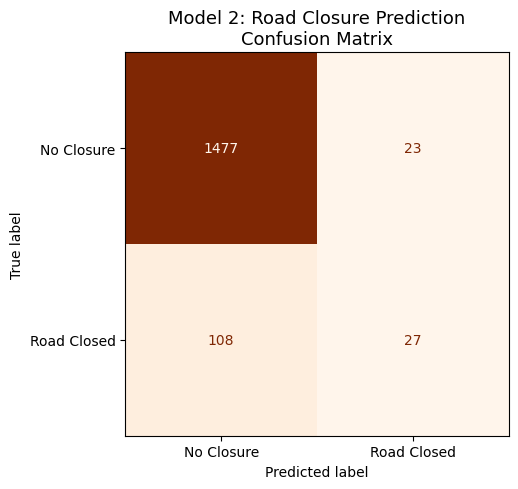

📊 Saved as confusion_matrix_closure.png


In [18]:
# ── Confusion Matrix for Model 2 ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm2 = confusion_matrix(y_test2, y_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2,
                                display_labels=['No Closure', 'Road Closed'])
disp2.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Model 2: Road Closure Prediction\nConfusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_closure.png', dpi=100, bbox_inches='tight')
plt.show()
print("📊 Saved as confusion_matrix_closure.png")


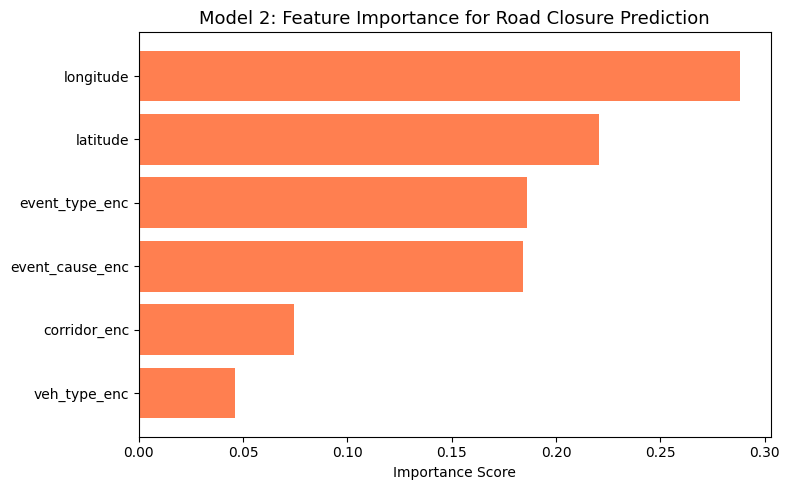

In [19]:
# ── Feature Importance for Model 2 ───────────────────────────────────────────
importances2 = gb_closure.feature_importances_
feat_df2 = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances2
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df2['Feature'], feat_df2['Importance'], color='coral')
plt.xlabel('Importance Score')
plt.title('Model 2: Feature Importance for Road Closure Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance_closure.png', dpi=100, bbox_inches='tight')
plt.show()


## 📊 Step 7: Cross-Validation

A single train-test split can sometimes give lucky or unlucky results.  
**Cross-validation** splits the data 5 different ways and tests each split — giving a more reliable accuracy estimate.


In [20]:
# 5-fold cross-validation for both models
cv_priority = cross_val_score(rf_priority, X, y_priority, cv=5, scoring='accuracy')
cv_closure  = cross_val_score(gb_closure,  X, y_closure,  cv=5, scoring='accuracy')

print("=== Cross-Validation Results (5-fold) ===")
print()
print(f"Model 1 (Priority Prediction):")
print(f"  Fold accuracies : {cv_priority.round(3)}")
print(f"  Mean Accuracy   : {cv_priority.mean()*100:.2f}%  ± {cv_priority.std()*100:.2f}%")
print()
print(f"Model 2 (Road Closure Prediction):")
print(f"  Fold accuracies : {cv_closure.round(3)}")
print(f"  Mean Accuracy   : {cv_closure.mean()*100:.2f}%  ± {cv_closure.std()*100:.2f}%")


=== Cross-Validation Results (5-fold) ===

Model 1 (Priority Prediction):
  Fold accuracies : [0.994 0.999 1.    0.999 0.997]
  Mean Accuracy   : 99.78%  ± 0.19%

Model 2 (Road Closure Prediction):
  Fold accuracies : [0.919 0.916 0.907 0.92  0.916]
  Mean Accuracy   : 91.56%  ± 0.47%


## 🔮 Step 8: Make Predictions on New Events

Now that both models are trained, we can use them to predict for any **new incoming event**.  
This is the core of the real-time forecasting system.


In [21]:
def predict_event_impact(event_cause, event_type, corridor, latitude, longitude, veh_type='Unknown'):
    """
    Given details of a new traffic event, predict:
    1. Priority (High / Low)
    2. Whether road closure is required (Yes / No)

    Parameters:
    -----------
    event_cause : str  e.g. 'vehicle_breakdown', 'tree_fall', 'accident'
    event_type  : str  'planned' or 'unplanned'
    corridor    : str  e.g. 'Tumkur Road', 'Non-corridor'
    latitude    : float
    longitude   : float
    veh_type    : str  e.g. 'heavy_vehicle', 'Unknown'

    Returns:
    --------
    dict with predicted priority and road closure recommendation
    """
    # Encode the inputs using the same encoders used during training
    def safe_encode(le, value):
        """Handle unseen labels gracefully"""
        if value in le.classes_:
            return le.transform([value])[0]
        else:
            return 0  # Default to first class if unseen

    row = np.array([[
        safe_encode(label_encoders['event_cause'],  event_cause),
        safe_encode(label_encoders['event_type'],   event_type),
        safe_encode(label_encoders['corridor'],     corridor),
        safe_encode(label_encoders['veh_type'],     veh_type),
        latitude,
        longitude
    ]])

    priority_pred = rf_priority.predict(row)[0]
    closure_pred  = gb_closure.predict(row)[0]

    priority_label = le_priority.inverse_transform([priority_pred])[0]
    closure_label  = "Yes — Deploy Barricades" if closure_pred == 1 else "No"

    return {
        'Priority'              : priority_label,
        'Road Closure Required' : closure_label,
        'Recommendation'        : (
            "🔴 HIGH URGENCY — Dispatch maximum manpower + barricades"
            if priority_label == 'High' and closure_pred == 1
            else "🟡 HIGH PRIORITY — Dispatch extra manpower"
            if priority_label == 'High'
            else "🟢 STANDARD — Normal response team sufficient"
        )
    }

print("✅ Prediction function ready!")


✅ Prediction function ready!


In [22]:
# ── Test Case 1: Unplanned vehicle breakdown on a major corridor ──────────────
result1 = predict_event_impact(
    event_cause='vehicle_breakdown',
    event_type='unplanned',
    corridor='Tumkur Road',
    latitude=13.04,
    longitude=77.52,
    veh_type='heavy_vehicle'
)

print("🚨 Test Event 1 — Heavy vehicle breakdown on Tumkur Road:")
for k, v in result1.items():
    print(f"   {k}: {v}")

print()

# ── Test Case 2: Planned public event ─────────────────────────────────────────
result2 = predict_event_impact(
    event_cause='public_event',
    event_type='planned',
    corridor='Mysore Road',
    latitude=12.96,
    longitude=77.54,
    veh_type='Unknown'
)

print("🎭 Test Event 2 — Planned public event on Mysore Road:")
for k, v in result2.items():
    print(f"   {k}: {v}")

print()

# ── Test Case 3: Tree fall ─────────────────────────────────────────────────────
result3 = predict_event_impact(
    event_cause='tree_fall',
    event_type='unplanned',
    corridor='Non-corridor',
    latitude=13.006,
    longitude=77.579,
    veh_type='Unknown'
)

print("🌳 Test Event 3 — Tree fall on non-corridor road:")
for k, v in result3.items():
    print(f"   {k}: {v}")


🚨 Test Event 1 — Heavy vehicle breakdown on Tumkur Road:
   Priority: High
   Road Closure Required: No
   Recommendation: 🟡 HIGH PRIORITY — Dispatch extra manpower

🎭 Test Event 2 — Planned public event on Mysore Road:
   Priority: High
   Road Closure Required: No
   Recommendation: 🟡 HIGH PRIORITY — Dispatch extra manpower

🌳 Test Event 3 — Tree fall on non-corridor road:
   Priority: Low
   Road Closure Required: No
   Recommendation: 🟢 STANDARD — Normal response team sufficient


## 💾 Step 9: Export Models as `.pkl` Files

Once the models are trained, we save them as **pickle (`.pkl`) files** so the backend team can load and use them directly — without retraining.

**What gets exported:**
| File | Contents |
|---|---|
| `model_priority.pkl` | Random Forest — Priority predictor |
| `model_closure.pkl` | Gradient Boosting — Road Closure predictor |
| `label_encoders.pkl` | All category encoders (needed to encode new input data) |
| `le_priority.pkl` | Priority label encoder (to decode prediction back to 'High'/'Low') |

> ⚠️ **Backend team note:** You must load `label_encoders.pkl` and `le_priority.pkl` alongside the models to correctly encode inputs and decode outputs.


In [23]:
import pickle
import os

# ── Create an output folder for all pkl files ─────────────────────────────────
os.makedirs("exported_models", exist_ok=True)

# ── 1. Save Model 1: Priority Predictor (Random Forest) ──────────────────────
with open("exported_models/model_priority.pkl", "wb") as f:
    pickle.dump(rf_priority, f)
print("✅ Saved: exported_models/model_priority.pkl")

# ── 2. Save Model 2: Road Closure Predictor (Gradient Boosting) ───────────────
with open("exported_models/model_closure.pkl", "wb") as f:
    pickle.dump(gb_closure, f)
print("✅ Saved: exported_models/model_closure.pkl")

# ── 3. Save all categorical Label Encoders ────────────────────────────────────
#    label_encoders is a dict: { 'event_cause': le, 'event_type': le, ... }
with open("exported_models/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)
print("✅ Saved: exported_models/label_encoders.pkl")

# ── 4. Save the Priority target Label Encoder ─────────────────────────────────
#    Needed to convert numeric prediction (0/1) back to 'High' / 'Low'
with open("exported_models/le_priority.pkl", "wb") as f:
    pickle.dump(le_priority, f)
print("✅ Saved: exported_models/le_priority.pkl")

print()
print("📦 All model files exported to 'exported_models/' folder.")
print()

# ── Verify file sizes ─────────────────────────────────────────────────────────
print("File sizes:")
for fname in os.listdir("exported_models"):
    fpath = os.path.join("exported_models", fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"   {fname:35s} → {size_kb:.1f} KB")


✅ Saved: exported_models/model_priority.pkl
✅ Saved: exported_models/model_closure.pkl
✅ Saved: exported_models/label_encoders.pkl
✅ Saved: exported_models/le_priority.pkl

📦 All model files exported to 'exported_models/' folder.

File sizes:
   le_priority.pkl                     → 0.2 KB
   label_encoders.pkl                  → 1.1 KB
   model_priority.pkl                  → 1329.2 KB
   model_closure.pkl                   → 223.0 KB


### 🔁 Backend Usage — How to Load & Use the Models

The backend team can use the snippet below in their Python server (Flask / FastAPI / Django etc.):


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# BACKEND USAGE EXAMPLE
# This block shows how the backend team should load and use the saved models.
# They do NOT need to retrain — just load the .pkl files and call predict().
# ─────────────────────────────────────────────────────────────────────────────

import pickle
import numpy as np

# ── Load everything ───────────────────────────────────────────────────────────
with open("exported_models/model_priority.pkl", "rb") as f:
    loaded_priority_model = pickle.load(f)

with open("exported_models/model_closure.pkl", "rb") as f:
    loaded_closure_model = pickle.load(f)

with open("exported_models/label_encoders.pkl", "rb") as f:
    loaded_label_encoders = pickle.load(f)

with open("exported_models/le_priority.pkl", "rb") as f:
    loaded_le_priority = pickle.load(f)

print("✅ All models loaded successfully!")
print()

# ── Helper: encode a single new event ────────────────────────────────────────
def encode_new_event(event_cause, event_type, corridor, veh_type,
                     latitude, longitude, encoders):
    def safe_encode(le, val):
        return le.transform([val])[0] if val in le.classes_ else 0

    return np.array([[
        safe_encode(encoders['event_cause'], event_cause),
        safe_encode(encoders['event_type'],  event_type),
        safe_encode(encoders['corridor'],    corridor),
        safe_encode(encoders['veh_type'],    veh_type),
        latitude,
        longitude
    ]])

# ── Run a prediction using loaded models ──────────────────────────────────────
new_event = encode_new_event(
    event_cause = 'accident',
    event_type  = 'unplanned',
    corridor    = 'Hosur Road',
    veh_type    = 'private_car',
    latitude    = 12.93,
    longitude   = 77.61,
    encoders    = loaded_label_encoders
)

priority_num = loaded_priority_model.predict(new_event)[0]
closure_num  = loaded_closure_model.predict(new_event)[0]

priority_str = loaded_le_priority.inverse_transform([priority_num])[0]
closure_str  = "Yes" if closure_num == 1 else "No"

print("🔮 Prediction for new incoming event:")
print(f"   Priority              : {priority_str}")
print(f"   Road Closure Required : {closure_str}")


✅ All models loaded successfully!

🔮 Prediction for new incoming event:
   Priority              : High
   Road Closure Required : No


## ✅ Step 10: Summary & Next Steps

### What we built:
| Model | Algorithm | Target | Use |
|---|---|---|---|
| Model 1 | Random Forest | Priority (High/Low) | Manpower allocation |
| Model 2 | Gradient Boosting | Road Closure (Yes/No) | Barricade deployment |

### How it answers the problem statement:
- **Forecast traffic impact** → Priority prediction tells responders how severe an event is likely to be
- **Recommend manpower** → High priority = more officers needed
- **Recommend barricading** → Road closure prediction drives barricade decisions
- **Diversion planning** → Corridor + location features can be extended to suggest alternate routes

### Possible Improvements:
1. Add **time features** (hour of day, day of week) — congestion varies by time
2. Use **geospatial clustering** to identify recurring hotspot locations  
3. Add **real-time weather data** (rain → more accidents, water-logging)
4. Try **XGBoost** or **LightGBM** for potentially better accuracy
5. Build an **API endpoint** so the model can receive live event feeds
